# Activity volcano

The activity volcano condenses the performance of an entire family of catalysts into a single plot by expressing the limiting potential as a function of one descriptor, ΔGOH. The left leg of the volcano is governed by OH desorption (too strong binding), and the right leg by OOH or O₂ activation (too weak binding). The peak is the theoretical maximum activity achievable within the scaling relation constraints, and real catalysts fall below it by their overpotential.

This notebook constructs the volcano in two stages.

1. the theoretical curve is plotted analytically by combining the two universal scaling relations (ΔGOOH = ΔGOH + 3.2 eV and ΔGO = 2·ΔGOH) with the four-step ORR free energy expression, sweeping ΔGOH from 0 to 2 eV and computing the limiting potential at each point.

2. real BEEF-vdW DFT data for seven FCC(111) metals is downloaded from a Zenodo database, corrected with literature ZPE, entropy, and solvation values, and placed onto the volcano as scatter points.

The notebook then introduces the BEEF-vdW ensemble: the database stores 2000 alternative functional energies alongside the central value, and their standard deviation gives a principled uncertainty estimate for each adsorption energy. These uncertainties are propagated to the volcano as error bars, with the important caveat that the non-differentiability of the min() function means the error bar direction is only correct when the limiting step does not change within the uncertainty range.

In [1]:
%%capture
!pip install ase

In [2]:
from ase.db import connect
from IPython.display import display

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

The volcano is built from two scaling relations — ${\text{OOH*}}$ binds ~3.2 eV stronger than


$$
\Delta G_{\text{OOH*}} = \Delta G_{\text{OH*}} + 3.2\ \text{eV}
$$


$$
\Delta G_{\text{O*}} = 2\,\Delta G_{\text{OH*}}
$$


which rThese reduce all four ORR intermediates to a single descriptor


$$
U_L = 1.23 V - \min(\Delta G_1,\ \Delta G_2,\ \Delta G_3,\ \Delta G_4)/e
$$


where each $\Delta G_i$ is expressed solely in terms of $\Delta G_{\text{OH*}}$ (Nørskov et al., *J. Phys. Chem. B* **108**, 17886, 2004; Man et al., *ChemCatChem* **3**, 1159, 2011).





Before looking at real catalysts, we plot the theoretical volcano curve. The limiting potential is determined by the least favorable elementary step, and by expressing all intermediates through the scaling relations, the entire curve becomes a function of ΔG_OH alone.

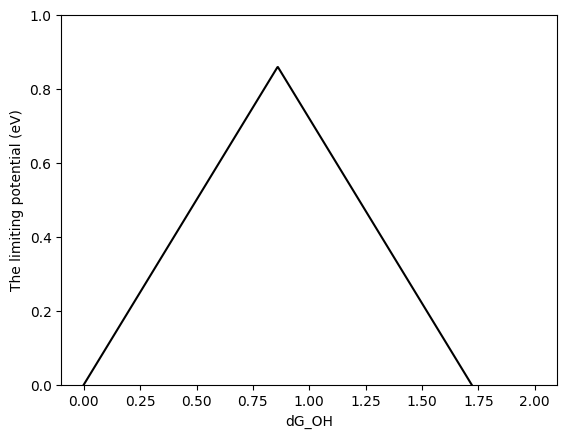

In [3]:
##-The overpotential can be calculated as the minimum distance between the reaction states-##
def overpotential(dG_OOH, dG_OH, dG_O):
  return min(4.92 - dG_OOH, dG_OOH - dG_O, dG_O - dG_OH, dG_OH)

fig, ax = plt.subplots()

ax.set_xlabel('dG_OH')
ax.set_ylabel('The limiting potential (eV)')
ax.set_ylim(bottom=0)

OH_line = np.linspace(0, 2, 1000)
U_lim = [overpotential(OH + 3.2, OH, OH * 2) for OH in OH_line]

ax.plot(OH_line, U_lim, c='black')

fig.show()

We now download the DFT database containing BEEF-vdW energies for a set of transition metal slabs and their adsorbates, along with molecular reference energies for H₂ and H₂O.

In [4]:
!wget -q https://zenodo.org/records/19023993/files/molecules.db?download=1 -O molecules.db
!wget -q https://zenodo.org/records/19023993/files/slab_database.db?download=1 -O slab_database.db
!wget -q https://zenodo.org/records/19023993/files/adsorbate_database.db?download=1 -O adsorbate_database.db

In [5]:
!ase db adsorbate_database.db --show-values structure_str

structure_str: Ag_111_OH_top(4), Ag_111_OOH_top(4), Cu_111_OH_top(4), Cu_111_OOH_top(4), Ir_111_OH_top(4), Ir_111_OOH_top(4), Pd_111_OH_top(4), Pd_111_OOH_top(4), Pt_111_OH_top(4), Pt_111_OOH_top(4), Rh_111_OH_top(4), Rh_111_OOH_top(4), Au_111_OH_top(4), Au_111_OOH_top(4), Ag_111_O_fcc(4), Au_111_O_fcc(4), Cu_111_O_fcc(4), Ir_111_O_fcc(4), Pd_111_O_fcc(4), Pt_111_O_fcc(4), Rh_111_O_fcc(4), Ag_111_O_top(4), Au_111_O_top(4), Cu_111_O_top(4), Ir_111_O_top(4), Pd_111_O_top(4), Pt_111_O_top(4), Rh_111_O_top(4), Ni_111_OH_top(4), Ni_111_OOH_top(4), Ag_100_OH_top(4), Au_100_OH_top(4), Cu_100_OH_top(4), Ir_100_OH_top(4), Pd_100_OH_top(4), Pt_100_OH_top(4), Rh_100_OH_top(4), Ag_100_OOH_top(4), Au_100_OOH_top(4), Cu_100_OOH_top(4), Ir_100_OOH_top(4), Pd_100_OOH_top(4), Pt_100_OOH_top(4), Rh_100_OOH_top(4), Au_111_OH_hollow(1), Cu_111_OH_hollow(1), Ir_111_OH_hollow(1), Ni_111_OH_hollow(1), Pd_111_OH_hollow(1), Pt_111_OH_hollow(1), Rh_111_OH_hollow(1)


Select data from

In [6]:
xc  = 'BEEF-vdW'
mol = [r for r in connect('molecules.db').select(xc=xc)]
met = [r for r in connect('slab_database.db').select(xc=xc)]
ads = [r for r in connect('adsorbate_database.db').select(xc=xc)]

Get the reference energies

In [7]:
E_H2  = [r.energy for r in mol if r.formula == 'H2'][0]
E_H2O = [r.energy for r in mol if r.formula == 'H2O'][0]

Create dictionaries with DFT energies indexed by structure name.

In [8]:
met_E = {r.key_value_pairs['structure_str']: r.get('energy') for r in met}
ads_E = {r.key_value_pairs['structure_str']: r.get('energy') for r in ads}

In [9]:
O_fcc = [name for name in ads_E if '_O_fcc' in name and ads_E[name] is not None]
OH_top = [name for name in ads_E if '_OH_top' in name and ads_E[name] is not None]
OOH_top = [name for name in ads_E if '_OOH_top' in name and ads_E[name] is not None]

OH_top.remove('Ni_111_OH_top')
OOH_top.remove('Ni_111_OOH_top')

The corrections for the free energies from: https://doi.org/10.1021/acssuschemeng.8b04173

%Recheck the reference

| Intermediate | SC / eV | ΔZPE − TΔS / eV |
|---|:---:|:---:|
| \*O | 0.00 | 0.05 |
| \*OH | −0.50 | 0.35 |
| \*OOH | −0.30 | 0.40 |

Here SC is the the solvent corections.

With the raw DFT energies extracted, we apply ZPE, entropy, and solvation corrections from the literature to convert electronic energies into adsorption free energies for O, OH, and OOH.

In [10]:
O_G = {}

for name in O_fcc:
  slab = name.replace('_O_fcc', '')
  EDFT = ads_E[name] - met_E[slab] - (E_H2O - E_H2)
  O_G[name] = EDFT + 0.05

OH_G = {}

for name in OH_top:
  slab = name.replace('_OH_top', '')
  EDFT = ads_E[name] - met_E[slab] - (E_H2O - 0.5 * E_H2)
  OH_G[name] = EDFT + 0.35 - 0.50

OOH_G = {}

for name in OOH_top:
  slab = name.replace('_OOH_top', '')
  EDFT = ads_E[name] - met_E[slab] - (2 * E_H2O - 1.5 * E_H2)
  OOH_G[name] = EDFT + 0.4 - 0.30

##-Here we create a simple dataframe to sort and work with our results-##
rows = []

for name in OH_G:
  O_name = name.replace('OH_top', 'O_fcc')
  OOH_name = name.replace('OH', 'OOH')

  rows.append(
    {
      'name': name,
      'metal': name.split('_111')[0],
      'dG_O': O_G[O_name],
      'dG_OH': OH_G[name],
      'dG_OOH': OOH_G[OOH_name],
      'dG_O_sd': np.nan,
      'dG_OH_sd': np.nan,
      'dG_OOH_sd': np.nan
    }
  )

df_results = pd.DataFrame(rows)

We collect all results into a table showing the adsorption free energies for each metal alongside their deviation from the universal scaling relations. Colors indicate how far each metal sits from the expected linear trend.

In [11]:
table = df_results.copy()

table['dG_O - 2dG_OH / eV'] = table['dG_O'] - 2 * table['dG_OH']
table['dG_OOH - dG_OH - 3.2 / eV'] = table['dG_OOH'] - table['dG_OH'] - 3.2

cols = [
  'metal',
  'dG_OH',
  'dG_O',
  'dG_OOH',
  'dG_O - 2dG_OH / eV',
  'dG_OOH - dG_OH - 3.2 / eV'
]

display(table[cols].sort_values('dG_OH', ascending=False).round(3))

,metal,dG_OH,dG_O,dG_OOH,dG_O - 2dG_OH / eV,dG_OOH - dG_OH - 3.2 / eV
6,Au,1.385,2.958,4.613,0.187,0.028
0,Ag,0.949,2.176,4.228,0.277,0.079
3,Pd,0.821,1.499,3.962,-0.142,-0.059
4,Pt,0.793,1.606,3.964,0.019,-0.030
1,Cu,0.528,0.939,3.837,-0.118,0.109
5,Rh,0.392,0.645,3.554,-0.139,-0.038
2,Ir,0.363,0.790,3.580,0.064,0.017


With adsorption free energies in hand, we can now place each metal onto the theoretical volcano curve and compare their predicted limiting potentials.

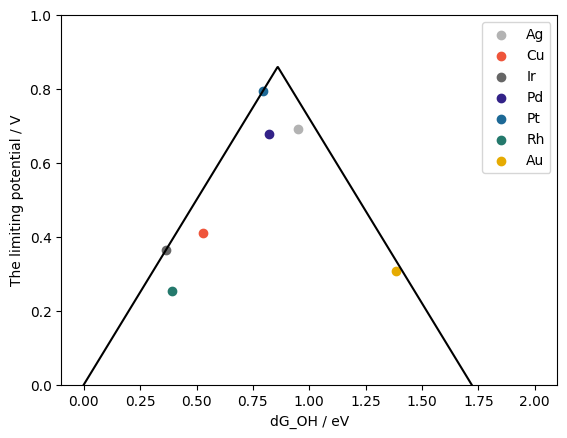

In [12]:
def overpotential_sd(dG_OOH, dG_OH, dG_O, dG_OH_sd, dG_OOH_sd, dG_O_sd):
  steps = [
    (4.92 - dG_OOH, dG_OOH_sd),
    (dG_OOH - dG_O, (dG_OOH_sd**2 + dG_O_sd**2)**0.5),
    (dG_O - dG_OH, (dG_O_sd**2 + dG_OH_sd**2)**0.5),
    (dG_OH, dG_OH_sd)
  ]

  limiting_step = min(steps, key=lambda step: step[0])

  return limiting_step[1]


def plot_volcano(df):
  colors = {
    'Pt': '#1d6996',
    'Cu': '#EF553B',
    'Pd': '#332288',
    'Rh': '#24796c',
    'Ag': '#b3b3b3',
    'Ir': '#666666',
    'Au': '#e6ab02'
  }

  fig, ax = plt.subplots()

  ax.set_xlabel('dG_OH / eV')
  ax.set_ylabel('The limiting potential / V')
  ax.set_ylim(bottom=0)

  OH_line = np.linspace(0, 2, 1000)
  U_lim = [overpotential(OH + 3.2, OH, OH * 2) for OH in OH_line]

  ax.plot(OH_line, U_lim, c='black')

  for i, row in df.iterrows():
    metal = row['metal']
    U_lim = overpotential(row['dG_OOH'], row['dG_OH'], row['dG_O'])

    ax.scatter(
      row['dG_OH'],
      U_lim,
      label=metal,
      c=colors[metal]
    )

    ##-The black volcano line uses scaling relations, while the metal points use calculated O adsorption energies-##
    if not np.isnan(row['dG_OH_sd']) and not np.isnan(row['dG_OOH_sd']) and not np.isnan(row['dG_O_sd']):
      yerr = overpotential_sd(
        row['dG_OOH'],
        row['dG_OH'],
        row['dG_O'],
        row['dG_OH_sd'],
        row['dG_OOH_sd'],
        row['dG_O_sd']
      )

      ax.errorbar(
        row['dG_OH'],
        U_lim,
        xerr=row['dG_OH_sd'],
        yerr=yerr,
        ecolor=colors[metal]
      )

  ax.legend()

  fig.show()

##-Here we plot the volcano-##
plot_volcano(df_results)


The BEEF-vdW functional is special in that it provides an ensemble of 2000 functionals trained to reproduce the expected error of a calculation. This allows us to attach uncertainty estimates to each data point on the volcano. Note that on the left side of the volcano, where the limiting step depends only on ΔG_OH, the error bars follow a diagonal direction rather than a vertical one.

The BEEF-vdW functional is special in that it have an ensemble of functional trained to reproduce the expected error of a calculation. With this we can no add errors each of our points.

It should also be noted that since the left side of the volcano is a function of only G_OH each error should follow a digonal.

In this data base all the 2000 ensemble energies are placed in the Data part, the order is consistent such that each list index match in all the other calculations.

In [13]:
mol_ens = {r.formula: r.data['ensemble_en'] for r in mol}
met_ens = {r.key_value_pairs['structure_str']: r.data['ensemble_en'] for r in met if 'ensemble_en' in dict(r.data)}
ads_ens = {r.key_value_pairs['structure_str']: r.data['ensemble_en'] for r in ads if 'ensemble_en' in dict(r.data)}

In [14]:
OH_ensemble_g = {}
OH_sigma = {}

for name in OH_top:
  slab = name.replace('_OH_top', '')

  if name in ads_ens and slab in met_ens:
    E_ens = ads_ens[name] - met_ens[slab] - (mol_ens['H2O'] - 0.5 * mol_ens['H2'])

    OH_sigma[name] = E_ens.std()
    OH_ensemble_g[name] = E_ens + 0.35 - 0.50

    df_results.loc[df_results['name'] == name, 'dG_OH_sd'] = OH_sigma[name]

In [15]:
OOH_ensemble_g = {}
OOH_sigma = {}

for name in OOH_top:
  slab = name.replace('_OOH_top', '')

  if name in ads_ens and slab in met_ens:
    E_ens = ads_ens[name] - met_ens[slab] - (2 * mol_ens['H2O'] - 1.5 * mol_ens['H2'])

    OOH_sigma[name] = E_ens.std()
    OOH_ensemble_g[name] = E_ens + 0.4 - 0.30

    df_results.loc[df_results['name'].str.startswith(slab), 'dG_OOH_sd'] = OOH_sigma[name]

In [16]:
O_ensemble_g = {}
O_sigma = {}

for name in O_fcc:
  slab = name.replace('_O_fcc', '')

  if name in ads_ens and slab in met_ens:
    E_ens = ads_ens[name] - met_ens[slab] - (mol_ens['H2O'] - mol_ens['H2'])

    O_sigma[name] = E_ens.std()
    O_ensemble_g[name] = E_ens + 0.05

    df_results.loc[df_results['name'].str.startswith(slab), 'dG_O_sd'] = O_sigma[name]

With uncertainties computed for all three intermediates, we update the table and re-plot the volcano with error bars. The increased spread in ΔG_O reflects its larger ensemble uncertainty relative to OH and OOH.

In [17]:
table = df_results.copy()

table['dG_O - 2dG_OH / eV'] = table['dG_O'] - 2 * table['dG_OH']
table['dG_OOH - dG_OH - 3.2 / eV'] = table['dG_OOH'] - table['dG_OH'] - 3.2

cols = [
  'metal',
  'dG_OH',
  'dG_O',
  'dG_OOH',
  'dG_O_sd',
  'dG_OH_sd',
  'dG_OOH_sd',
  'dG_O - 2dG_OH / eV',
  'dG_OOH - dG_OH - 3.2 / eV'
]

display(table[cols].sort_values('dG_OH', ascending=False).round(3))

,metal,dG_OH,dG_O,dG_OOH,dG_O_sd,dG_OH_sd,dG_OOH_sd,dG_O - 2dG_OH / eV,dG_OOH - dG_OH - 3.2 / eV
6,Au,1.385,2.958,4.613,0.156,0.160,0.236,0.187,0.028
0,Ag,0.949,2.176,4.228,0.168,0.157,0.269,0.277,0.079
3,Pd,0.821,1.499,3.962,0.236,0.173,0.297,-0.142,-0.059
4,Pt,0.793,1.606,3.964,0.247,0.166,0.259,0.019,-0.030
1,Cu,0.528,0.939,3.837,0.252,0.180,0.303,-0.118,0.109
5,Rh,0.392,0.645,3.554,0.191,0.191,0.294,-0.139,-0.038
2,Ir,0.363,0.790,3.580,0.143,0.192,0.301,0.064,0.017


Since the Min() function of the overpotential is not differentiable, it is assumed that the error will not cause the limiting step to change. This is offcause a rather heavy approximation. Clearest sign of this is that the left side of the theoretical volcano is simply Overpotential=ΔG_OH, so no point should be over it.  

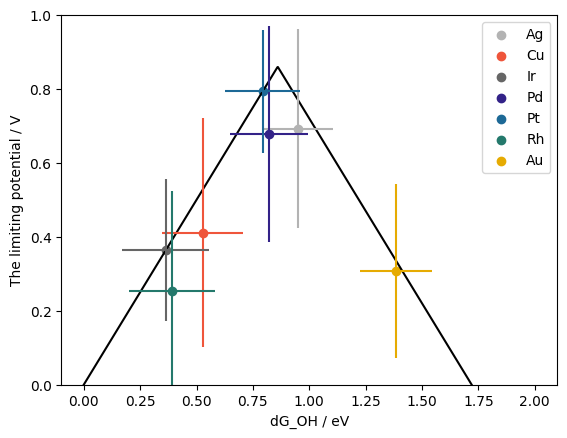

In [19]:
plot_volcano(df_results)

#Summary

After completing this notebook, you should be able to:

1. Plot the theoretical volcano curve. Express all four ORR step free energies in terms of ΔGOH alone using the two scaling relations, compute the limiting potential as the minimum step energy over a sweep of ΔGOH values, and plot the result as the theoretical upper bound on ORR activity.
2. Apply free energy corrections to DFT energies. Add ZPE, entropy (TΔS), and solvation corrections from the literature to raw electronic adsorption energies for O (fcc hollow), OH (top), and OOH (top), and understand what each correction accounts for physically.
3.  Compute ΔGOH for each metal, evaluate the actual limiting potential from the three corrected adsorption free energies (without assuming scaling), and scatter the result onto the theoretical curve.
4. Recognize that on the left leg of the volcano, where the limiting step is OH desorption, the error in the limiting potential equals the error in ΔGOH directly, so error bars should be diagonal rather than purely vertical, and that the non-differentiability of min() is a limitation of simple error propagation when the limiting step could change within the uncertainty range.